In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict

from langchain_core.prompts import PromptTemplate

load_dotenv()

True

In [5]:
model = ChatOpenAI()

In [ ]:
template1 = PromptTemplate(
    template= "Create a detailed outline of the following topic:\n{topic}",
    input_variables= ["topic"]
)

template2 = PromptTemplate(
    template = """
    Create a 500 word blog on the {topic} as per the below outline.\n
    Outline: {outline}
    """,
    input_variables=['topic', 'outline']
)

In [23]:
# define state
class BlogState(TypedDict):

    topic: str
    outline: str
    blog: str
    eval_score: int

In [36]:
def generate_outline(state: BlogState) -> BlogState:
    topic = state['topic']
    prompt = template1.format(topic = topic)

    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state


def generate_blog(state: BlogState) -> BlogState:
    topic = state['topic']
    outline = state['outline']

    prompt = template2.format(topic = topic, outline = outline)

    blog = model.invoke(prompt).content

    state['blog'] = blog

    return state


def evaluate_blog(state: BlogState) -> BlogState:
    outline = state['outline']
    blog = state['blog']

    prompt = f"""
    Based on the below outline rate the blog between 1 and 10. 10 being the best and 1 being the worst

    Outline: {outline}

    Blog : {blog}
    """
    class Evaluation(TypedDict):
        eval_score: int

    eval_score = model.with_structured_output(Evaluation).invoke(prompt)['eval_score']

    state['eval_score'] = eval_score

    return state

In [37]:
# create graph
graph = StateGraph(BlogState)

# add nodes
graph.add_node("generate_outline", generate_outline)
graph.add_node("generate_blog", generate_blog)
graph.add_node("evaluate_blog", evaluate_blog)


# add edges
graph.add_edge(START, "generate_outline")
graph.add_edge("generate_outline", "generate_blog")
graph.add_edge("generate_blog", "evaluate_blog")
graph.add_edge("evaluate_blog", END)

#compile
workflow = graph.compile()


In [38]:
initial_state = {
    "topic": "Artificial Intelligence"
}

final_state = workflow.invoke(initial_state)

c:\Users\apaks\Desktop\LangGraph-Tutorials\myenv\Lib\site-packages\langchain_openai\chat_models\base.py:2493: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [39]:
final_state

{'topic': 'Artificial Intelligence',
 'outline': 'I. Introduction\nA. Definition of artificial intelligence (AI)\nB. Brief history and development of AI\nC. Importance and applications of AI in various industries\n\nII. Types of Artificial Intelligence\nA. Narrow AI\n1. Definition and examples\n2. Characteristics and limitations\nB. General AI\n1. Definition and examples\n2. Possibilities and challenges\n\nIII. Approaches to Artificial Intelligence\nA. Symbolic AI\n1. Description and examples\n2. Logic-based reasoning\nB. Machine Learning\n1. Definition and examples\n2. Neural networks and deep learning\nC. Natural Language Processing\n1. Definition and examples\n2. Sentiment analysis and chatbots\n\nIV. Ethical and Social Implications of Artificial Intelligence\nA. Job automation and displacement\nB. Bias in AI algorithms\nC. Privacy and security concerns\nD. Impact on society and human behavior\n\nV. Future Trends in Artificial Intelligence\nA. Advancements in AI technologies\nB. Int

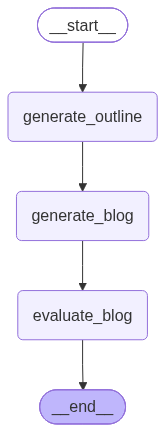

In [28]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())